In [2]:
library(WGCNA)

setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/bulk/GTEx/cortex")

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/module_projection_fxns.R")


Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘qvalue’


The following object is masked from ‘package:WGCNA’:

    qvalue


Loading required package: future


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘data.table’


The following objects are masked from ‘package:reshape2’:

    dcast, melt


The following objects are masked from ‘package:dplyr’:

    between, first, last




Using FM to get modules for specific cell types has been challenging. 

Instead, using known marker genes, I'll try to select correlated genes that are cell type-specific, as verified by projecting genes onto scRNA-seq data.

In [3]:
marker_source <- "Claude_marker_genes"

human_marker_genes_list <- readRDS("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/marker_genes/AI/Claude_cortical_markers_human.RDS")

mouse_marker_genes_list <- readRDS("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/marker_genes/AI/Claude_cortical_markers_mouse.RDS")

In [ ]:
sc_data_source <- "yao_2021_MOp_STAR_gene_counts_normalized"

sc_expr1 <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/scRNA-seq/yao_2021/MOp/yao_2021_MOp_STAR_gene_counts.csv", data.table=FALSE)
sampleinfo1 <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/scRNA-seq/yao_2021/MOp/yao_2021_MOp_STAR_sampleinfo.csv", data.table=FALSE)
colnames(sc_expr1)[1] <- "Gene"

# Remove cell types with only a few cells

min_cells <- 5

ctype_tally <- table(sampleinfo$subclass_label)
ctypes_to_keep <- names(ctype_tally)[ctype_tally >= min_cells]
cells_to_keep <- which(sampleinfo$subclass_label %in% ctypes_to_keep)

sc_expr <- sc_expr[, c(1, cells_to_keep + 1)]
sampleinfo <- sampleinfo[cells_to_keep,]

all.equal(colnames(sc_expr)[-1], sampleinfo$Cell_ID)

total_expr <- colSums(sc_expr[,-1])
sc_expr_norm <- sweep(sc_expr[,-1], MARGIN=2, FUN="/", STATS=total_expr) * 1e4
sc_expr_norm <- data.frame(Gene=sc_expr[,1], sc_expr_norm) 

ctype_assignment_vec <- sampleinfo$subclass_label

[1] TRUE

## GTEx_cortex_counts_TMMF_All_501_outliers_removed

In [ ]:
bulk_data_source <- "GTEx_cortex_counts_TMMF_All_501_outliers_removed" 
bulk_expr_file <- "GTEx_cortex_counts_TMMF_SampleNetworks/All_02-25-12/GTEx_cortex_counts_TMMF_All_501_outliers_removed.csv"
bulk_expr <- fread(bulk_expr_file, data.table=FALSE)

mean_expr <- data.frame(
    Index=1:nrow(bulk_expr), 
    Gene=bulk_expr[,1], 
    Expr=rowMeans(bulk_expr[,-1])
)

mean_expr <- mean_expr %>%
    group_by(Gene) %>%
    slice_max(Expr, with_ties=FALSE)

print(dim(mean_expr))

bulk_expr <- bulk_expr[mean_expr$Index,]

colnames(bulk_expr)[1] <- "Gene"
rownames(bulk_expr) <- bulk_expr[,1]

[1] 56027     3


In [8]:
# # Subset to genes in the top X percentile for generating modules

# prob <- .6
# mean_expr <- rowMeans(bulk_expr[,-1])

# subset_cutoff <- unname(quantile(mean_expr, prob))
# print(paste("quantile(mean_expr, prob):", round(subset_cutoff, 3)))
# subset <- mean_expr >= subset_cutoff
# sum(subset)

[1] "quantile(mean_expr, prob): 10.171"


[1] 22411

In [9]:
bulk_cor <- WGCNA::cor(t(bulk_expr[,-1]))
bulk_cor[1:5,1:4]

,5S_rRNA,5_8S_rRNA,7SK,A1BG
5S_rRNA,1.000000000,0.03303957,-0.001590826,0.09047914
5_8S_rRNA,0.033039568,1.00000000,0.012413658,0.06616714
7SK,-0.001590826,0.01241366,1.000000000,0.10479821
A1BG,0.090479140,0.06616714,0.104798211,1.00000000
A1BG-AS1,0.105490714,0.05706447,0.067556499,0.31744723


In [10]:
human_marker_genes_list

$`All Neuronal`
[1] "RBFOX3" "MAP2"   "SNAP25" "SYT1"   "TUBB3"  "ENO2"   "NRGN"   "STMN2" 
[9] "THY1"  

$`All Glutamatergic`
[1] "SLC17A7" "CAMK2A"  "SATB2"   "SLC17A6" "TBR1"    "EMX1"    "NEUROD2"
[8] "NEUROD6"

$`All GABAergic`
[1] "GAD1"    "GAD2"    "SLC32A1" "DLX1"    "DLX2"    "DLX5"    "DLX6"   

$`CGE Class`
[1] "ADARB2" "NR2F2"  "PROX1"  "HTR3A"  "SP8"   

$`MGE Class`
[1] "LHX6"   "NKX2-1" "SOX6"   "MAF"    "MAFB"  

$`L2/3 IT`
[1] "CUX2"      "LINC00507" "CUX1"      "MDGA1"     "OTOF"      "RASGRF2"  
[7] "LAMP5"    

$`L4 IT`
[1] "RORB"   "RSPO1"  "COL5A2" "CTXN3"  "THSD7A" "WHRN"  

$`L5 IT`
[1] "DEPTOR"  "THEMIS"  "BATF3"   "HSD11B1" "PDE1C"   "TCERG1L"

$`L5 ET`
 [1] "BCL11B" "BCL6"   "FAM84B" "FEZF2"  "CDH13"  "CHRNA6" "CRYM"   "NNAT"  
 [9] "NPNT"   "POU3F1"

$`L5/6 NP`
[1] "TRHR"     "TSHZ2"    "HTR2C"    "NXPH4"    "SERPINE2" "SLC17A8" 

$`L6 CT`
[1] "FOXP2" "SYT6"  "NTNG2" "NXPH2" "TLE4" 

$`L6 IT`
[1] "FOXP2"   "OPRK1"   "SLA"     "THEMIS"  "ZNF804B"

$`L6 IT Car3`
[1] "CA3"   "LXN"   "NR2F2"

$L6b
[1] "CCN2"      "NXPH4"     "CPLX3"     "INPP4B"    "OR2T8"     "RGS12"    
[7] "SERPINB11" "TRH"      

$Lamp5
[1] "LAMP5" "DOCK5" "LCP2"  "LSP1"  "NDNF"  "NTN1"  "PLCH2" "RELN" 

$`Lamp5 Lhx6`
[1] "LAMP5"  "LHX6"   "NKX2-1" "RXFP3" 

$Sncg
[1] "SNCG"  "CALB2" "CCK"   "CNR1"  "NPY2R" "PENK" 

$Vip
[1] "VIP"    "CALB2"  "CHAT"   "CRH"    "GPC3"   "MYBPC1" "TAC3"  

$Pax6
[1] "PAX6" "NPY"  "RELN"

$Pvalb
[1] "PVALB" "ERBB4" "KCNC1" "MYO5B" "SYT2"  "TAC1"  "KCNC2" "PTHLH"

$Chandelier
[1] "PVALB"  "UNC5B"  "VIPR2"  "CPNE5"  "NOS1"   "SNHG14"

$Sst
 [1] "SST"    "CALB1"  "CALB2"  "CBLN4"  "CHRNA2" "ETV1"   "HPSE"   "MYH8"  
 [9] "NPY"    "TH"     "RELN"  

$`Sst Chodl`
[1] "CHODL" "SST"   "NOS1"  "NPY"   "TACR1" "MME"  

$Astro
 [1] "ALDH1L1" "AQP4"    "GFAP"    "SLC1A2"  "SLC1A3"  "ALDOC"   "FGFR3"  
 [8] "GJA1"    "GLUL"    "NDRG2"   "S100B"   "SOX9"    "ACSL6"   "AGT"    
[15] "APOE"    "PLA2G7"  "SLC7A10"

$Oligo
 [1] "MBP"    "MOG"    "PLP1"   "CLDN11" "CNP"    "ERMN"   "MAG"    "MOBP"  
 [9] "OPALIN" "ENPP6"  "FA2H"   "KLK6"   "TF"     "UGT8A" 

$OPC
 [1] "CSPG4"  "PDGFRA" "GPR17"  "NKX2-2" "OLIG1"  "OLIG2"  "SOX10"  "VCAN"  
 [9] "BCAN"   "PCDH15" "PTPRZ1"

$`Micro/PVM`
 [1] "CTSS"    "CX3CR1"  "ITGAM"   "P2RY12"  "TMEM119" "TYROBP"  "AIF1"   
 [8] "C1QA"    "C1QB"    "C1QC"    "CSF1R"   "HEXB"    "SALL1"   "SPI1"   
[15] "TREM2"   "SELPLG" 

$Endo
 [1] "CLDN5"   "FLT1"    "EMCN"    "NOSTRIN" "PECAM1"  "SLCO1A4" "TEK"    
 [8] "VWF"     "BSG"     "ITM2A"   "LY6C1"  

$VLMC
 [1] "COL1A1"  "COL1A2"  "DCN"     "LUM"     "CD44"    "COL3A1"  "IL33"   
 [8] "OGN"     "PTGDS"   "SLC6A13" "SPP1"   

$Peri
 [1] "ABCC9"  "KCNJ8"  "PDGFRB" "ANPEP"  "CSPG4"  "MCAM"   "NOTCH3" "RGS5"  
 [9] "VTN"    "DES"    "DLK1"

In [293]:
gene_hooks <- c("SYT6")
bulk_cor_subset <- bulk_cor[rownames(bulk_cor) %in% gene_hooks,]
bulk_cor_subset <- sort(bulk_cor_subset, decreasing=TRUE)
head(data.frame(bulk_cor_subset), 10)

,bulk_cor_subset
,<dbl>
SYT6,1.0000000
SLC17A8,0.8153871
RAB3B,0.7842574
PID1,0.7757350
MMD,0.7645853
TENM1,0.7634009
PCDH17,0.7629608
CRHBP,0.7624888
GPRIN3,0.7624304


In [294]:
ctype <- "L5 ET"
marker_cor <- bulk_cor_subset[names(bulk_cor_subset) %in% human_marker_genes_list[[ctype]]]
print(marker_cor)
markers <- names(marker_cor)[marker_cor > 0.7]
markers

    BCL11B       NNAT      CDH13      FEZF2     CHRNA6       CRYM     POU3F1 
 0.6788512  0.6713921  0.5664897  0.5134200  0.3490723  0.3236589  0.2920918 
      NPNT       BCL6 
 0.2478002 -0.0173726 


character(0)

In [295]:
markers <- names(bulk_cor_subset)[1:10]
markers

[1] "SYT6"      "SLC17A8"   "RAB3B"     "PID1"      "MMD"       "TENM1"    
 [7] "PCDH17"    "CRHBP"     "GPRIN3"    "LINC02762"

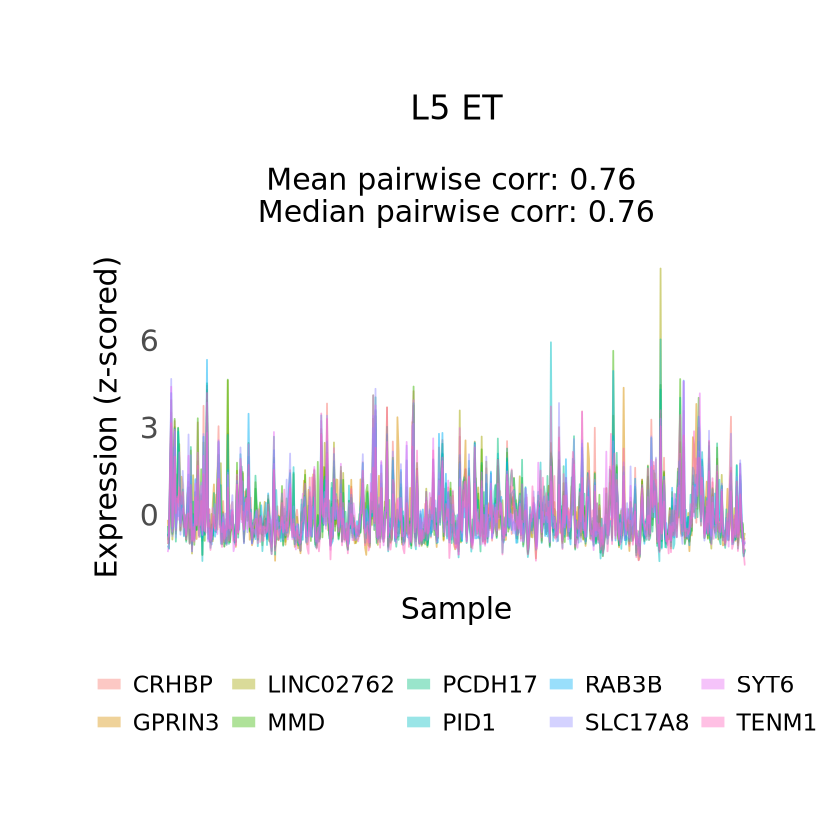

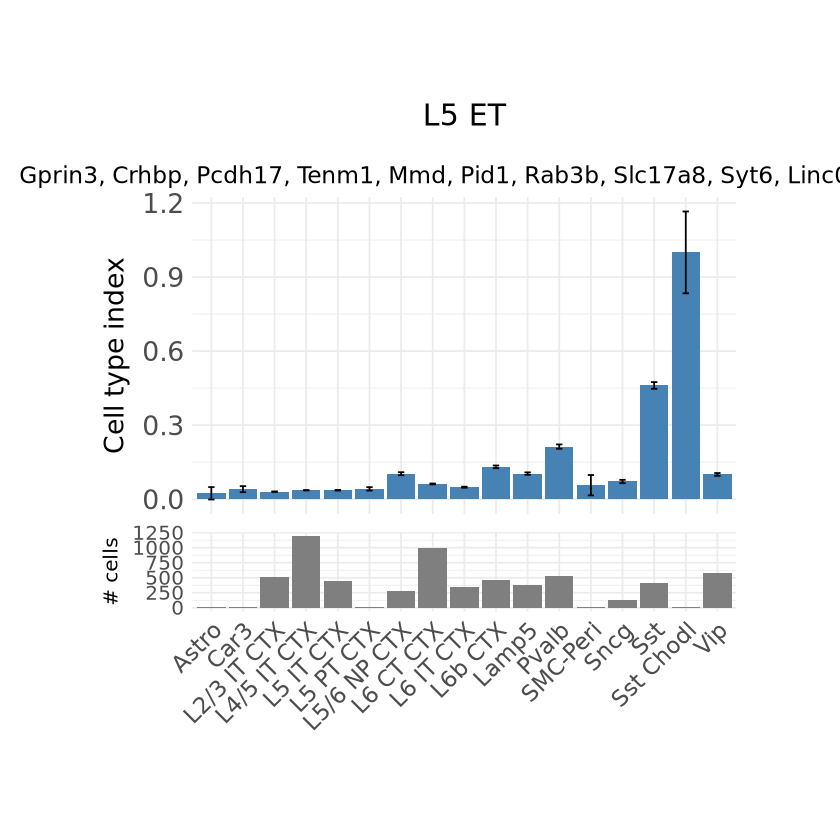

In [296]:
gene_vec <- markers

plot_title <- ctype 
plot_sub <- NULL

plot_gene_expr_over_samples(bulk_expr, gene_vec, plot_title, plot_sub)
plot_gene_projections(sc_expr_norm, gene_vec, ctype_assignment_vec, plot_title, plot_sub, target_species="mouse")

In [69]:
target_species <- "mouse"
expr <- sc_expr_norm
gene_vec <- markers

In [75]:
if (!is.null(target_species)) {
    gene_vec <- convert_genes(gene_vec, target_species)
}


In [82]:

ctype_index_list <- get_module_ctype_index(expr, gene_vec, ctype_assignment_vec)

ctype_index <- ctype_index_list[[1]]
ctype_index_se <- ctype_index_list[[2]] 

In [85]:
df <- data.frame(
    Cell_type=names(ctype_index),
    Index=ctype_index,
    SE=ctype_index_se,
    No.cells=as.numeric(table(ctype_assignment_vec))
)

plot_sub <- paste0(plot_sub, "\n", paste(na.omit(gene_vec[1:10]), collapse=", "))

In [89]:
index_plot <- ggplot(data=df, aes(x=Cell_type, y=Index)) +
    geom_bar(stat="identity", fill="steelblue") +
    geom_errorbar(aes(ymin=Index-2*SE, ymax=Index+2*SE), width=0.2) +
    labs(y="Cell type index") +
    theme_minimal() +
    theme(
        plot.title=element_text(size=18, hjust=0.5),
        plot.subtitle=element_text(size=14, hjust=0.5),
        axis.title.x=element_blank(),
        axis.text.x=element_blank(),  # Remove labels from top
        axis.text.y=element_text(size=16),
        axis.title.y=element_text(size=16)
    ) +
    labs(title=plot_title, subtitle=plot_sub)

n_cells_plot <- ggplot(data=df, aes(x=Cell_type, y=No.cells)) +
    geom_bar(stat="identity", fill="gray50") +
    labs(y="# cells") +
    theme_minimal() +
    theme(
        axis.title.x=element_blank(),
        axis.text.x=element_text(size=14, angle=45, hjust=1),
        axis.title.y=element_text(size=12),
        axis.text.y=element_text(size=12)
    ) 

# # Stack them
print(index_plot / n_cells_plot + plot_layout(heights=c(4, 1)))

ERROR: Error: Can't find method for generic `/(e1, e2)`:
- e1: <ggplot2::ggplot>
- e2: <ggplot2::ggplot>
